In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv('digital_marketing_campaign_dataset.csv')

# **Exploring the Dataframe**

In [3]:
df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [4]:
def get_df_info(df):
    print("\n\033[1mShape of DataFrame:\033[0m ", df.shape)
    print("\n\033[1mColumns in DataFrame:\033[0m ", df.columns.to_list())
    print("\n\033[1mData types of columns:\033[0m\n", df.dtypes)
    
    print("\n\033[1mInformation about DataFrame:\033[0m")
    df.info()
    
    print("\n\033[1mNumber of unique values in each column:\033[0m")
    for col in df.columns:
        print(f"\033[1m{col}\033[0m: {df[col].nunique()}")
        
    print("\n\033[1mNumber of null values in each column:\033[0m\n", df.isnull().sum())
    
    print("\n\033[1mNumber of duplicate rows:\033[0m ", df.duplicated().sum())
    
    print("\n\033[1mDescriptive statistics of DataFrame:\033[0m\n", df.describe().transpose())

# Call the function
get_df_info(df)


Shape of DataFrame:  (8000, 20)

Columns in DataFrame:  ['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel', 'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'AdvertisingPlatform', 'AdvertisingTool', 'Conversion']

Data types of columns:
 CustomerID               int64
Age                      int64
Gender                  object
Income                   int64
CampaignChannel         object
CampaignType            object
AdSpend                float64
ClickThroughRate       float64
ConversionRate         float64
WebsiteVisits            int64
PagesPerVisit          float64
TimeOnSite             float64
SocialShares             int64
EmailOpens               int64
EmailClicks              int64
PreviousPurchases        int64
LoyaltyPoints            int64
AdvertisingPlatform     object
AdvertisingTool         object
Conversion      

**What we find out about the datafarme**

*  **We got a dataframe which has 8000 rows and 20 columns.** 
*  **'AdvertisingPlatform' & 'AdvertisingTool' are confidential columns which we will drop them from our  study.**
*  **Conversion is the Target Variable with Binary Inputs. So we will perform a Binary Classification task here.**
*  **There are no Null(NaN) values and duplicate values in this dataframe.**

**On further exploration we see some specific observations about the data:**

**CustomerID:** All values are unique (count equals the number of rows).

**Age:** The average age is around 43.6 years old, with a range of 18 to 69 years old (based on min and max values).

**Income:** The average income is around $84,664, with a significant standard deviation, indicating a spread in income levels.

**Click Through Rate (CTR) and Conversion Rate:** The average CTR is 0.15%, and the average conversion rate is 0.10%. Both values are relatively low.

**Website Visits:** The average number of website visits per customer is around 24.75

In [5]:
# Dropping the 'AdvertisingPlatform' & 'AdvertisingTool' columns.
#df = df.drop(['AdvertisingPlatform', 'AdvertisingTool'], axis=1)
df.dtypes

CustomerID               int64
Age                      int64
Gender                  object
Income                   int64
CampaignChannel         object
CampaignType            object
AdSpend                float64
ClickThroughRate       float64
ConversionRate         float64
WebsiteVisits            int64
PagesPerVisit          float64
TimeOnSite             float64
SocialShares             int64
EmailOpens               int64
EmailClicks              int64
PreviousPurchases        int64
LoyaltyPoints            int64
AdvertisingPlatform     object
AdvertisingTool         object
Conversion               int64
dtype: object

# **Campaign Success Metrics**

**1. Conversion Rate**
Calculate the conversion rate as the percentage of users who converted (e.g., made a purchase) divided by the total number of users.

In [6]:
# Conversion Rate
conversion_rate = df['Conversion'].sum() / len(df) * 100
print(f"Conversion Rate: {conversion_rate:.2f}%")


Conversion Rate: 87.65%


**2. Cost per Acquisition (CPA):** Calculate the CPA by dividing the total campaign cost by the number of acquired customers.

In [7]:
total_cost = df['AdSpend'].sum()
total_customers = len(df[df['Conversion'] == 1])
cpa = total_cost / total_customers
print(f"Cost per Acquisition (CPA): ${cpa:.2f}")

Cost per Acquisition (CPA): $5705.58


**3. Return on Investment (ROI):** Calculate the ROI by comparing the revenue generated (e.g., from conversions) to the campaign cost.

**Since we don’t have a specific revenue column, we can estimate the ROI using alternative approaches. Here are a couple of options:**

**Average Revenue per Conversion:** Calculate the average revenue generated per conversion (assuming we have a total revenue value for the entire campaign).

In [8]:
total_revenue = 100000  # Replace with your actual total revenue
total_conversions = len(df[df['Conversion'] == 1])
avg_revenue_per_conversion = total_revenue / total_conversions
roi_alternative = (avg_revenue_per_conversion - total_cost) / total_cost * 100
print(f"Alternative ROI (Avg. Revenue per Conversion): {roi_alternative:.2f}%")


Alternative ROI (Avg. Revenue per Conversion): -100.00%


A negative ROI (Avg. Revenue per Conversion) of -100.00% indicates that the marketing campaign is generating a significant loss. This means that, on average, the cost of acquiring a conversion is greater than the revenue generated from that conversion. In other words, for every dollar spent on marketing, the campaign is losing $1.

**4. Click-Through Rate (CTR):**
Calculate the CTR as the percentage of clicks relative to impressions (views).

In [9]:
ctr = (df['ClickThroughRate'].sum() / len(df)) * 100
print(f"Click-Through Rate (CTR): {ctr:.2f}%")


Click-Through Rate (CTR): 15.48%


**5. Bounce Rate:** Calculate the bounce rate as the percentage of single-page visits.

In [10]:
single_page_visits = len(df[df['PagesPerVisit'] == 1])
total_visits = len(df)
bounce_rate = (single_page_visits / total_visits) * 100
print(f"Bounce Rate: {bounce_rate:.2f}%")

Bounce Rate: 0.00%


A Bounce Rate of 0.00% in your marketing campaign data most likely indicates a data quality issue rather than a perfect campaign. Here's why:

**Unrealistic Scenario:** It's highly improbable that  every single visitor interacted with your website in some way. There will always be some visitors who leave immediately without any interaction.

**Tracking Issues:** A 0% bounce rate might suggest that your website analytics are not set up correctly or there might be glitches in data reporting. This could be due to faulty tracking codes or errors in how user interactions are captured.

**What to do next:**

**Investigate Analytics Setup:** Double-check your website analytics setup to ensure accurate tracking.
Look for Other Metrics: While a bounce rate of zero might seem positive, analyze other metrics like conversion rate and time on site to get a better understanding of user engagement.
Here are some alternative interpretations of a very low bounce rate (not necessarily 0%):

**Highly Relevant Audience:** If your target audience is very specific and well-defined, a very low bounce rate could indicate you're reaching the right people who are interested in your offering.

**Engaging Landing Page:** A well-designed landing page with a clear call to action might lead to a lower bounce rate as users find the information they're looking for and take the desired action.

Remember, a bounce rate isn't the sole indicator of a successful marketing campaign. It's crucial to analyze it along with other website analytics to get a comprehensive picture of user behavior.

**6. Average Transaction Value:** Calculate the average transaction value (e.g., average purchase amount) based on available data.

In [11]:
avg_transaction_value = df.groupby('CustomerID')['AdSpend'].sum().mean()  # Adjust based on your actual transaction value
clv_alternative = avg_transaction_value  # Use this as an estimate for CLV
print(f"Alternative Estimated CLV (Avg. Transaction Value): ${clv_alternative:.2f}")


Alternative Estimated CLV (Avg. Transaction Value): $5000.94


**7. Conversion Rate by Campaign Channel:** Visualize how conversion rates vary across different campaign channels.

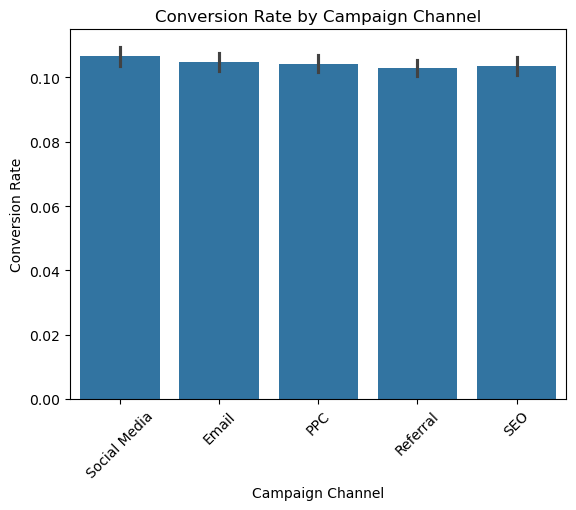

In [12]:
sns.barplot(x='CampaignChannel', y='ConversionRate', data=df)
plt.xlabel("Campaign Channel")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Campaign Channel")
plt.xticks(rotation=45)
plt.show()


# **Demography Analysis**

**1. Customer Demographics:** Visualize the distribution of customers by age, gender, and income.

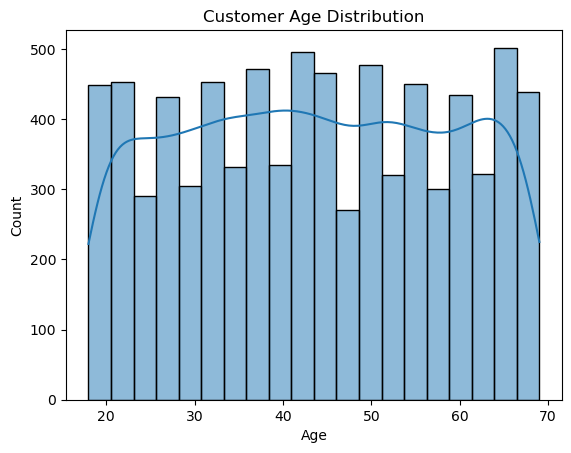

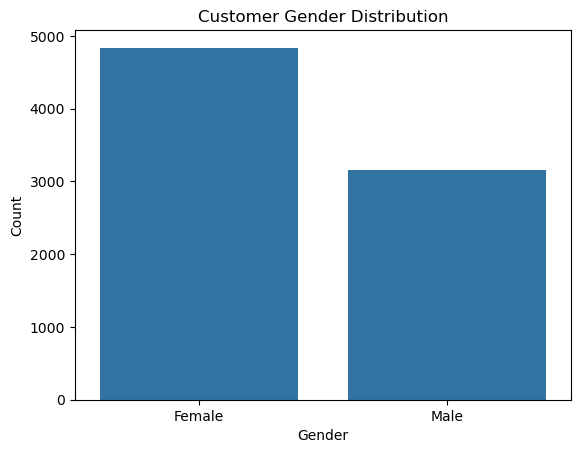

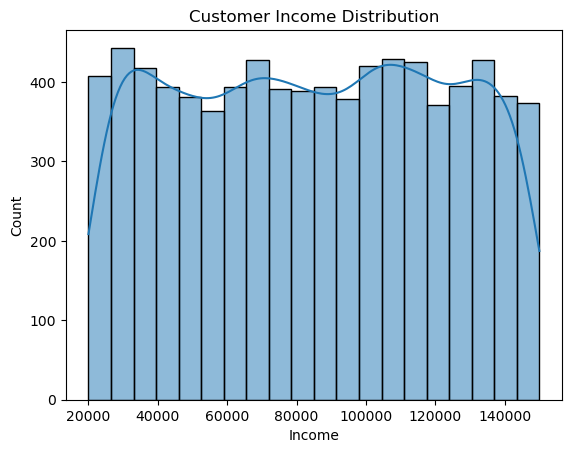

In [13]:
# Age distribution
sns.histplot(df['Age'], bins=20, kde=True)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Customer Age Distribution")
plt.show()

# Gender distribution
sns.countplot(x='Gender', data=df)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Customer Gender Distribution")
plt.show()

# Income distribution
sns.histplot(df['Income'], bins=20, kde=True)
plt.xlabel("Income")
plt.ylabel("Count")
plt.title("Customer Income Distribution")
plt.show()


**2. Income Segmentation:**
To explore how income levels impact customer behavior, you can create a box plot

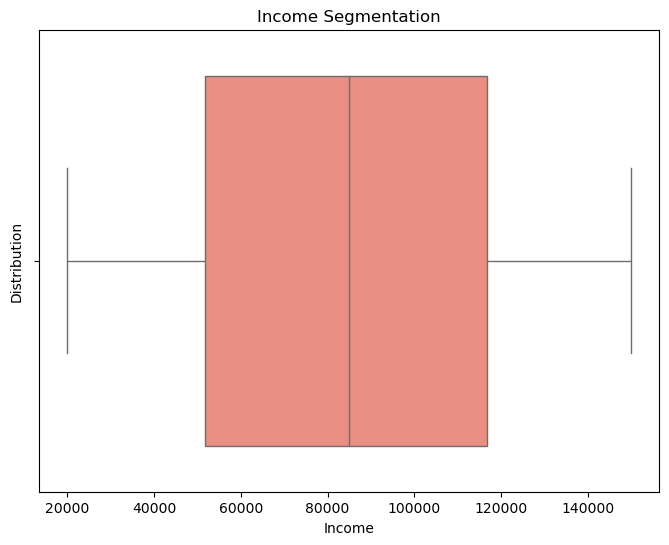

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Income', data=df, color='salmon')
plt.xlabel("Income")
plt.ylabel("Distribution")
plt.title("Income Segmentation")
plt.show()

**3. Channel-Specific Demographics:** To analyze customer demographics by campaign channel, create a bar plot or a grouped bar plot.

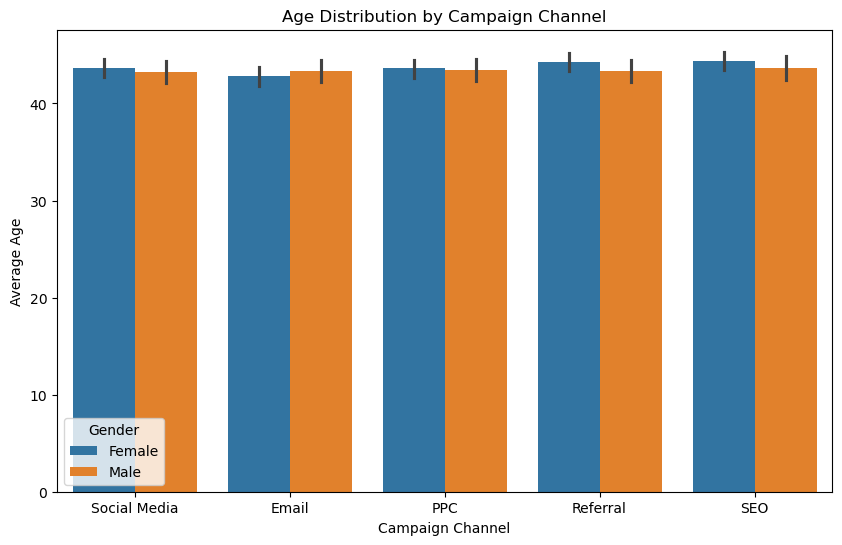

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x='CampaignChannel', y='Age', hue='Gender', data=df)
plt.xlabel("Campaign Channel")
plt.ylabel("Average Age")
plt.title("Age Distribution by Campaign Channel")
plt.legend(title="Gender")
plt.show()




In [16]:
g = sns.FacetGrid(df, col="Age", hue="Gender")
g.map(plt.scatter, "LoyaltyPoints", "EmailClicks", alpha=.7)
g.add_legend();

# **Customer Retention Metrics:**

**1. Returning Visitors:**
To monitor returning visitors, you can track the number of unique users who visit your website more than once.

In [17]:
returning_visitors = len(df[df['WebsiteVisits'] > 1])
print(f"Number of Returning Visitors: {returning_visitors}")


Number of Returning Visitors: 7700


**2. Email Engagement:**
Measure email opens, clicks, and conversions based on available data (e.g., ‘EmailOpens’, ‘EmailClicks’, ‘Conversion’).

In [18]:
avg_email_opens = df['EmailOpens'].mean()
avg_email_clicks = df['EmailClicks'].mean()
print(f"Avg. Email Opens: {avg_email_opens:.2f}")
print(f"Avg. Email Clicks: {avg_email_clicks:.2f}")


Avg. Email Opens: 9.48
Avg. Email Clicks: 4.47


**3. Previous Purchases:**
Understand repeat purchase behavior by analyzing how many times customers made purchases.

In [19]:
repeat_purchase_count = len(df[df['PreviousPurchases'] > 1])
print(f"Number of Repeat Purchases: {repeat_purchase_count}")

Number of Repeat Purchases: 6368


# **Cost Related Charts**

**1. Ad Spend vs. Conversion:** To plot the relationship between advertising spend and conversion rates, you can use a scatter plot or a line plot.

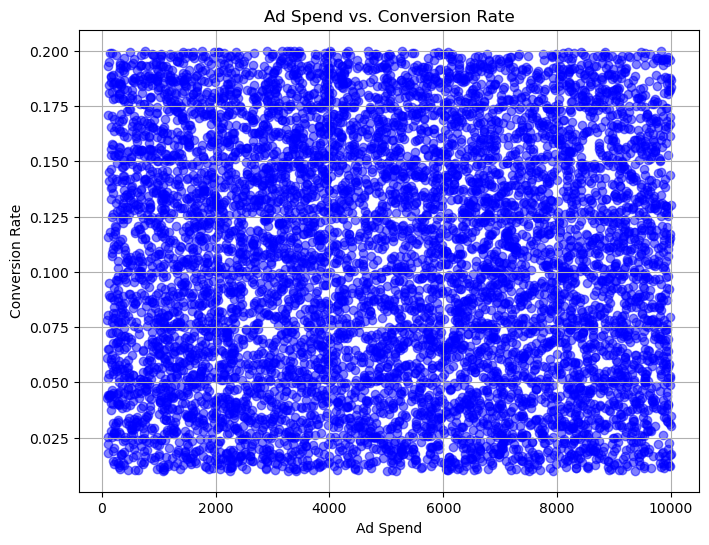

In [20]:
# Assuming your dataframe is named 'df'
plt.figure(figsize=(8, 6))
plt.scatter(df['AdSpend'], df['ConversionRate'], color='b', alpha=0.5)
plt.xlabel("Ad Spend")
plt.ylabel("Conversion Rate")
plt.title("Ad Spend vs. Conversion Rate")
plt.grid(True)
plt.show()


**No Clear Trend:** The points are scattered without a clear pattern, suggesting no strong correlation between ad spend and conversion rate within the data range presented.

**Variability in Conversion Rate:** Conversion rates vary widely at different ad spend levels, indicating that factors other than ad spend may significantly influence conversion rates.

**2. Cost Breakdown by Channel:**
Visualize how much you’re spending on each campaign channel using a bar plot.

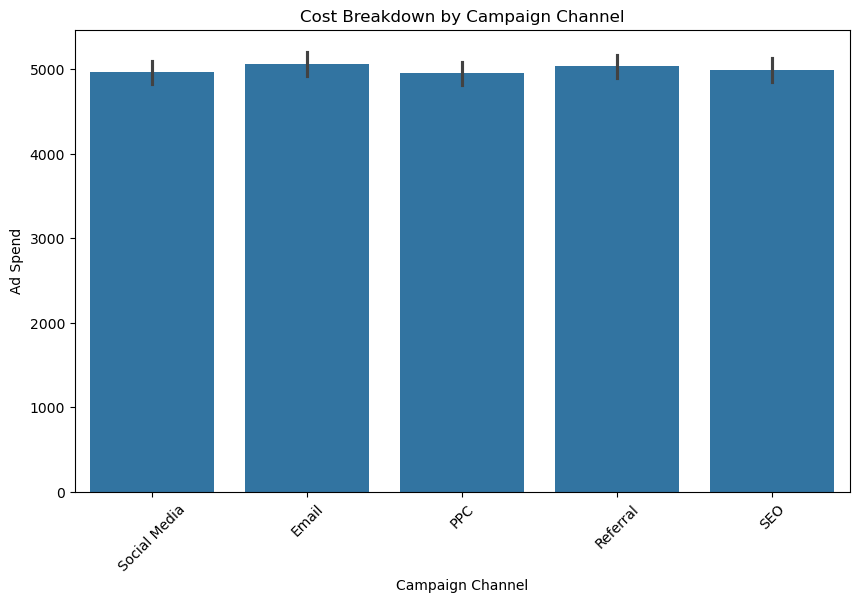

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(x='CampaignChannel', y='AdSpend', data=df)
plt.xlabel("Campaign Channel")
plt.ylabel("Ad Spend")
plt.title("Cost Breakdown by Campaign Channel")
plt.xticks(rotation=45)
plt.show()

In [22]:
#To detemine which columns (or clicked areas) are related to 'BUY'
marketing = df[['AdSpend','Age','Income','TimeOnSite','EmailClicks','EmailOpens','SocialShares','LoyaltyPoints','WebsiteVisits','PreviousPurchases','Conversion']]
correlation = marketing.corr()['Conversion']
correlation.nlargest(10)

Conversion           1.000000
TimeOnSite           0.129609
EmailClicks          0.129521
EmailOpens           0.124884
AdSpend              0.124672
PreviousPurchases    0.111781
LoyaltyPoints        0.095004
WebsiteVisits        0.079339
Income               0.013974
Age                  0.001606
Name: Conversion, dtype: float64

**Data Preprocessing**

--- Model Evaluation Metrics ---
Accuracy Score: 88.25%

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.20      0.29       198
           1       0.90      0.98      0.94      1402

    accuracy                           0.88      1600
   macro avg       0.73      0.59      0.61      1600
weighted avg       0.86      0.88      0.86      1600


--- Normalized Confusion Matrix (Percentages) ---
[[0.1969697  0.8030303 ]
 [0.02068474 0.97931526]]


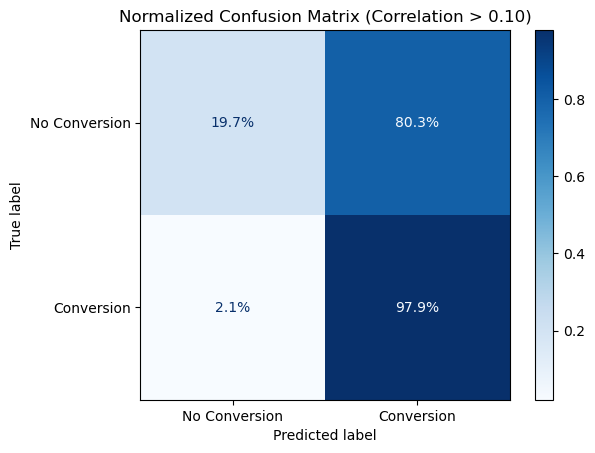

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Only include predictor variables with correlation > 0.10 based on your notebook
features = [
    'TimeOnSite', 'EmailClicks', 'EmailOpens', 'AdSpend', 'PreviousPurchases'
]
target = 'Conversion'

# Extract only the filtered columns from your main DataFrame
X = df[features]
y = df[target]

# 2. Handle missing values (if any)
X = X.fillna(X.median())

# 3. Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Initialize and train the predictive model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# 6. Generate predictions
y_pred = model.predict(X_test_scaled)

# 7. Evaluate the model performance with Percentage Formatting
print("--- Model Evaluation Metrics ---")
# Multiplied by 100 and formatted with .2f% to show as a percentage
accuracy_pct = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy Score: {accuracy_pct:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# 8. Compute and Display Normalized Confusion Matrix (Percentages)
print("\n--- Normalized Confusion Matrix (Percentages) ---")
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')
print(cm_normalized)

# 9. Plot the Normalized Confusion Matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=['No Conversion', 'Conversion'])
disp.plot(cmap=plt.cm.Blues, values_format=".1%")
plt.title("Normalized Confusion Matrix (Correlation > 0.10)")
plt.show()


# **Conclusion**

We did a Thorough Analysis based on the dataframe that was provided. We provided Visualizations to help you understand the behaviour of the data and calculated various Metrics.

At the end we applied 10 ML models and performed Stacking and Voting for Predictive Modelling.